# Off-Policy Monte Carlo with Importance Sampling — and Why It Goes Wild

### In-Class Exercise #1 (19 Jun) · Reinforcement Learning

We are studying the two **Monte Carlo (MC) Off-Policy** pseudocodes from Sutton & Barto:

1. **Off-Policy MC Prediction** — *evaluate* a target policy `π` using episodes generated by a different behavior policy `b`.
2. **Off-Policy MC Control** — *improve* toward the optimal policy while still acting with a soft behavior policy `b`.

The glue that makes "learn about one policy while following another" possible is **importance sampling**.
Our main mission today is the last bullet of the exercise:

> *Show how the algorithm can produce a **large variance** in value distributions.*

So after we implement both algorithms faithfully, we spend most of our energy on **pictures of that variance**.

## What You'll Learn

1. What **off-policy** learning means, and why we'd ever want it.
2. What the **importance-sampling ratio** is, in plain language.
3. How to translate the Sutton & Barto **MC Off-Policy Prediction** pseudocode into running Python — and watch the key variables `G`, `W`, `C`, `Q` change.
4. How to translate the **MC Off-Policy Control** pseudocode into Python — including the tricky `argmax` target policy and the inner-loop **break**.
5. The difference between **ordinary** and **weighted** importance sampling.
6. **The big one:** *why* ordinary importance sampling can have **enormous (even infinite) variance**, demonstrated with graphs you can present.

## Key Vocabulary

| Term | Simple Explanation |
|------|--------------------|
| **Policy** | A rule that says which action to take in each state. Think of it as a game-playing strategy. |
| **Target policy `π`** | The strategy we actually *care about* and want to learn the value of. |
| **Behavior policy `b`** | The strategy we *actually follow* to collect experience. Often more exploratory. |
| **Off-policy** | Learning about `π` while following a *different* policy `b`. Like learning to cook a dish by watching someone improvise. |
| **Return `G`** | The total (discounted) reward collected from a time step until the episode ends. The "final score" from here on. |
| **Importance-sampling ratio `ρ` (rho)** | A correction factor `π(a\|s) / b(a\|s)` multiplied along the trajectory. It re-weights experience so it *counts as if* `π` had produced it. |
| **`W`** | The running importance-sampling weight inside the algorithm — the product of those `π/b` ratios. |
| **`C(s,a)`** | The running **sum of weights** seen so far for a state-action pair. The denominator for weighted averaging. |
| **`Q(s,a)`** | Our current estimate of the value of taking action `a` in state `s` and then following `π`. |
| **Ordinary importance sampling** | Average of `ρ·G`, dividing by the **number of episodes** `N`. Unbiased, but can have **huge variance**. |
| **Weighted importance sampling** | Average of `ρ·G`, dividing by the **sum of weights** `Σρ`. Slightly biased, but **much** lower variance. |
| **Variance** | How wildly a quantity bounces around its average from run to run. High variance = untrustworthy estimates. |

### Setup

We import our tools and fix the plotting style. Setting a random seed everywhere we can keeps results reproducible — *run it again, get the same picture.*

In [1]:
# --- Standard data-science toolkit ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Suppress warnings so the lecture output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

# A clean, classroom-friendly plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# seed = 42 so every run of this notebook looks identical.
# (RL is full of randomness; pinning the seed makes the lecture reproducible.)
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

print("Toolkit ready. NumPy", np.__version__)

Toolkit ready. NumPy 2.4.6


---
# Part 1 — The Big Idea Behind Importance Sampling

### An everyday analogy: studying from a friend's messy notes

Imagine you want to know **how well you'd score on an exam if you studied exactly the way the top student studies** (that's the *target policy* `π`).
But you don't study that way — you study your *own* way, jumping around topics (that's the *behavior policy* `b`).

You still want to estimate the top student's expected score using **your** study sessions. Importance sampling does this by **re-weighting** each of your sessions:

- If you happened to study a topic the top student also emphasises → that session is **up-weighted** (it looks like their style).
- If you studied something they'd *never* touch → that session gets weight **zero** (it tells us nothing about their style).

The math version of that weight, for one episode, is the **importance-sampling ratio**:

$$\rho_{t:T-1} \;=\; \prod_{k=t}^{T-1} \frac{\pi(A_k\mid S_k)}{b(A_k\mid S_k)}$$

That product is the star of today's show. When the two policies disagree a lot, this product can become **astronomically large** for a few lucky trajectories — and that is exactly where *large variance* is born.

---
# Part 2 — Off-Policy MC **Prediction** (Weighted Importance Sampling)

Here is the pseudocode we are translating (Sutton & Barto):

```
Input: a target policy π
Initialize, for all s, a:
    Q(s,a) ∈ ℝ   (arbitrary)
    C(s,a) ← 0
Loop forever (for each episode):
    b ← any policy with coverage of π
    Generate an episode following b:  S0,A0,R1,...,S_{T-1},A_{T-1},R_T
    G ← 0
    W ← 1
    Loop for each step t = T-1, T-2, ..., 0,  while W ≠ 0:
        G ← γ·G + R_{t+1}
        C(St,At) ← C(St,At) + W
        Q(St,At) ← Q(St,At) + (W / C(St,At)) · [G − Q(St,At)]
        W ← W · π(At|St) / b(At|St)
```

**Reading it like a recipe (back-to-front!):**

- We walk the episode **backwards** (end → start), because the return `G` is naturally built from the final reward.
- `G` is the running return; `C(s,a)` is the running **sum of weights** (the *weighted* part).
- The `Q` update nudges our estimate toward `G`, by an amount proportional to this episode's weight `W`.
- `W` is multiplied by `π/b` *after* the update, so the next (earlier) step gets corrected by what followed it.
- The loop stops early **while W ≠ 0**: once a step has zero target-probability, everything earlier is zero-weight too.

### A tiny world to test on: the "one-state" MDP

To keep every variable visible, we use Sutton & Barto's famous **one-state world** (Example 5.5).

- A single non-terminal state `s`. Two actions: **LEFT** and **RIGHT**.
- **RIGHT** → episode ends immediately, reward **0**.
- **LEFT** → with probability **0.9** you come *back to `s`* (reward 0); with probability **0.1** the episode ends with reward **+1**.

**Target policy `π`:** always go **LEFT**.  **Behavior policy `b`:** flip a coin — LEFT or RIGHT with probability 0.5 each.

Under "always LEFT", every episode eventually ends with reward +1, so the **true value is `v_π(s) = 1`**. Keep that number in mind — it's the bullseye every estimate is aiming at.

In [2]:
# Action labels for readability
LEFT, RIGHT = 0, 1
ACTION_NAMES = {LEFT: "LEFT", RIGHT: "RIGHT"}

# Target policy pi: always LEFT  ->  pi(LEFT|s)=1, pi(RIGHT|s)=0
def pi_prob(action):
    return 1.0 if action == LEFT else 0.0

# Behavior policy b: 50/50 coin flip  ->  b(LEFT|s)=b(RIGHT|s)=0.5
B_LEFT_PROB = 0.5
def b_prob(action):
    return B_LEFT_PROB if action == LEFT else (1.0 - B_LEFT_PROB)

def generate_one_state_episode(rng):
    """Play ONE episode of the one-state world using behavior policy b.
    Returns a list of (state, action, reward) tuples. State is always 's'."""
    episode = []
    while True:
        action = LEFT if rng.random() < B_LEFT_PROB else RIGHT
        if action == RIGHT:
            episode.append(('s', RIGHT, 0))      # RIGHT -> terminal, reward 0
            break
        # action == LEFT
        if rng.random() < 0.1:
            episode.append(('s', LEFT, 1))       # 10% chance: terminal, reward +1
            break
        else:
            episode.append(('s', LEFT, 0))       # 90% chance: back to s, reward 0
    return episode

# Quick peek at a few episodes so we trust the simulator
demo_rng = np.random.default_rng(0)
for i in range(5):
    ep = generate_one_state_episode(demo_rng)
    pretty = " -> ".join(f"{ACTION_NAMES[a]}(r={r})" for _, a, r in ep)
    print(f"Episode {i+1}: {pretty}")

Episode 1: RIGHT(r=0)
Episode 2: LEFT(r=1)
Episode 3: LEFT(r=0) -> RIGHT(r=0)
Episode 4: RIGHT(r=0)
Episode 5: RIGHT(r=0)


**What do we see here?**

- Most episodes are short and often end the instant the coin says **RIGHT** (reward 0).
- Occasionally the agent flips LEFT several times in a row before terminating.
- Those rare *all-LEFT* runs are the ones that matter for `π` (which only ever goes LEFT) — and, as we'll see, they're the troublemakers for variance.

### Implement the prediction pseudocode *with a key-variable trace*

The exercise asks us to **"add stubs to show the key variables."** So our function can optionally print `G`, `W`, `C`, `Q` at every step of the backward loop — exactly the variables named in the pseudocode.

In [3]:
def off_policy_mc_prediction(num_episodes, gamma=1.0, seed=0, trace=False):
    """Weighted-importance-sampling MC prediction, faithful to the pseudocode.

    Estimates Q(s, a) for the target policy pi (always-LEFT) in the one-state world.
    If trace=True, prints the key variables for the FIRST episode so we can watch
    the algorithm think.
    """
    rng = np.random.default_rng(seed)

    # Initialize Q arbitrarily (zeros) and C to 0 -- exactly as the pseudocode says
    Q = defaultdict(float)   # Q[(state, action)]
    C = defaultdict(float)   # C[(state, action)] = running sum of weights

    history = []  # record Q(s, LEFT) after each episode to plot convergence

    for ep in range(num_episodes):
        episode = generate_one_state_episode(rng)

        G = 0.0
        W = 1.0
        do_trace = trace and ep == 0
        if do_trace:
            print(f"=== Tracing episode 0 (length {len(episode)}) ===")
            print(f"Episode: {[ (ACTION_NAMES[a], r) for _, a, r in episode ]}\n")

        # Walk the episode BACKWARDS:  t = T-1, ..., 0   while W != 0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward                 # running return
            C[(state, action)] += W                # sum of weights
            # weighted incremental update toward the return G
            Q[(state, action)] += (W / C[(state, action)]) * (G - Q[(state, action)])

            if do_trace:
                print(f"  t={t}: A={ACTION_NAMES[action]:5s} R={reward} | "
                      f"G={G:6.3f}  W={W:8.3f}  "
                      f"C(s,{ACTION_NAMES[action]})={C[(state,action)]:8.3f}  "
                      f"Q(s,{ACTION_NAMES[action]})={Q[(state,action)]:6.4f}")

            # Update the importance weight for the NEXT (earlier) step
            W *= pi_prob(action) / b_prob(action)
            if W == 0:                              # 'while W != 0' early exit
                if do_trace:
                    print(f"  -> W hit 0 (took {ACTION_NAMES[action]}, which pi never does). Stop.")
                break

        history.append(Q[('s', LEFT)])

    return Q, C, np.array(history)

In [4]:
# Run a short trace so we can SEE the key variables move
print("True target value we are aiming for:  v_pi(s) = 1.0\n")
Q_demo, C_demo, _ = off_policy_mc_prediction(num_episodes=8, seed=7, trace=True)
print("\nAfter 8 episodes:")
print(f"  Q(s, LEFT)  = {Q_demo[('s', LEFT)]:.4f}")
print(f"  Q(s, RIGHT) = {Q_demo[('s', RIGHT)]:.4f}")
print(f"  C(s, LEFT)  = {C_demo[('s', LEFT)]:.4f}   (sum of weights)")

True target value we are aiming for:  v_pi(s) = 1.0

=== Tracing episode 0 (length 1) ===
Episode: [('RIGHT', 0)]

  t=0: A=RIGHT R=0 | G= 0.000  W=   1.000  C(s,RIGHT)=   1.000  Q(s,RIGHT)=0.0000
  -> W hit 0 (took RIGHT, which pi never does). Stop.

After 8 episodes:
  Q(s, LEFT)  = 0.0000
  Q(s, RIGHT) = 0.0000
  C(s, LEFT)  = 0.0000   (sum of weights)


**Key Insight — what the trace shows:**

- We process each episode **back-to-front**, building `G` from the last reward.
- `W` starts at `1`. Every LEFT action multiplies it by `π/b = 1/0.5 = 2` (a LEFT means `π` agreed, so the weight *grows*).
- The moment the behavior policy took a **RIGHT**, `π(RIGHT)=0`, so `W` becomes `0` and we **stop** — that episode tells us nothing about the always-LEFT target.
- Notice how `W` can **double, double, double** on long all-LEFT episodes. That doubling is the seed of the variance monster in Part 4.

Now let's run it for many episodes and confirm the estimate homes in on the true value **1.0**.

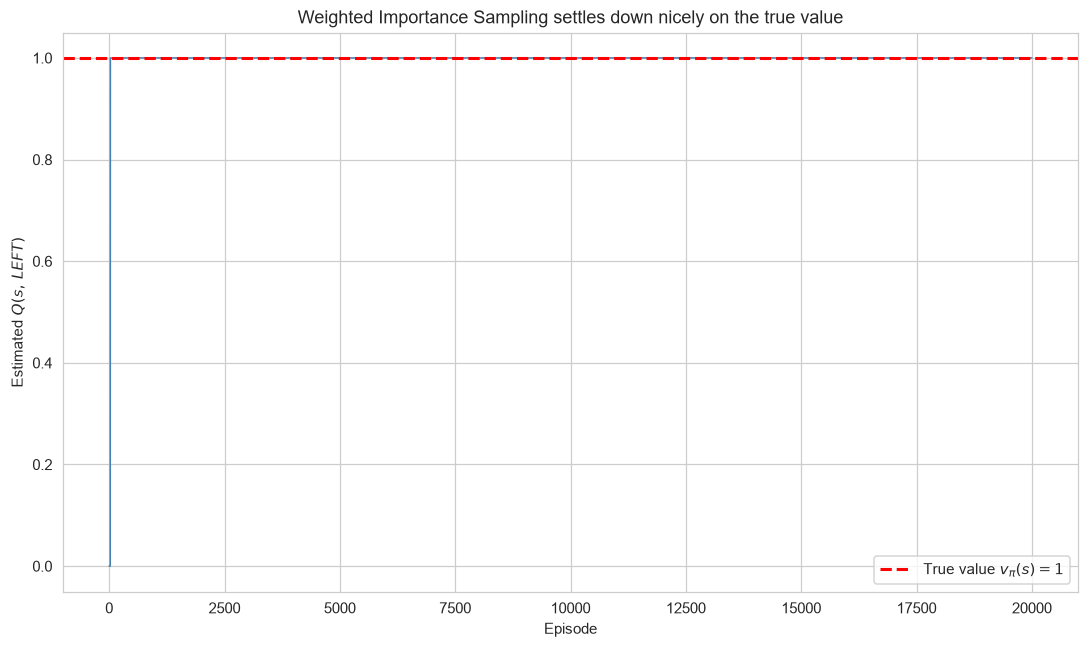

Final weighted-IS estimate of Q(s, LEFT): 1.0000  (target = 1.0)


In [5]:
Q_full, C_full, history = off_policy_mc_prediction(num_episodes=20000, seed=GLOBAL_SEED)

plt.figure(figsize=(10, 6))
plt.plot(history, color='steelblue', lw=1)
plt.axhline(1.0, color='red', ls='--', lw=2, label='True value $v_\\pi(s)=1$')
plt.xlabel('Episode')
plt.ylabel('Estimated $Q(s,\\,LEFT)$')
plt.title('Weighted Importance Sampling settles down nicely on the true value')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final weighted-IS estimate of Q(s, LEFT): {Q_full[('s', LEFT)]:.4f}  (target = 1.0)")

**What do we see here?**

- The estimate is jumpy at first (few samples) but **converges to ~1.0** and stays calm.
- This is the *good* behavior of **weighted** importance sampling. Hold this picture in mind — in Part 4 we run the *ordinary* version on the **same world** and watch it refuse to settle down.

---
# Part 3 — Off-Policy MC **Control**

Prediction *evaluates* a fixed policy. **Control** *improves* the policy. The pseudocode:

```
Initialize, for all s, a:
    Q(s,a) ∈ ℝ   (arbitrary)
    C(s,a) ← 0
    π(s)   ← argmax_a Q(s,a)         (ties broken consistently)
Loop forever (for each episode):
    b ← any soft policy
    Generate an episode using b:  S0,A0,R1,...,S_{T-1},A_{T-1},R_T
    G ← 0
    W ← 1
    Loop for each step t = T-1, ..., 0:
        G ← γ·G + R_{t+1}
        C(St,At) ← C(St,At) + W
        Q(St,At) ← Q(St,At) + (W / C(St,At)) · [G − Q(St,At)]
        π(St)   ← argmax_a Q(St,a)    (ties broken consistently)
        If At ≠ π(St)  then exit inner Loop (proceed to next episode)
        W ← W · 1 / b(At|St)
```

**Two new wrinkles vs. prediction:**

1. The **target policy is greedy**: `π(s) = argmax_a Q(s,a)`. Being greedy, `π(a|s)` is `1` (best action) or `0`. That's why the weight update simplifies to `W ← W · 1/b(At|St)` — the `π` numerator is `1`.
2. There's a hard **break**: the moment the behavior action `At` differs from the greedy `π(St)`, we stop. Everything earlier would be zero-weight anyway. So **control only learns from the *greedy tail* of each episode.**

### A small world for control: a 4×4 GridWorld

- A 4×4 grid. The agent starts at the **top-left** corner `(0,0)`; the **goal** is the **bottom-right** corner `(3,3)`.
- Every step costs **−1**; reaching the goal ends the episode. So the agent wants the **shortest path**.
- Actions: **up, right, down, left**. Bumping a wall keeps you in place.

**Behavior policy `b`:** uniform random (each action probability `0.25`). That's a *soft* policy (every action possible), so it "covers" the greedy target — a requirement for off-policy learning.

In [6]:
class GridWorld:
    """A 4x4 shortest-path grid. Reward -1 per step, episode ends at the goal."""
    def __init__(self, size=4):
        self.size = size
        self.goal = (size - 1, size - 1)
        self.actions = [0, 1, 2, 3]                 # up, right, down, left
        self.action_arrows = {0: 'U', 1: 'R', 2: 'D', 3: 'L'}

    def start_state(self):
        return (0, 0)

    def step(self, state, action):
        r, c = state
        if   action == 0: r -= 1     # up
        elif action == 1: c += 1     # right
        elif action == 2: r += 1     # down
        elif action == 3: c -= 1     # left
        # Walls: clamp back inside the grid (bumping a wall = stay put)
        r = min(max(r, 0), self.size - 1)
        c = min(max(c, 0), self.size - 1)
        next_state = (r, c)
        if next_state == self.goal:
            return next_state, 0, True      # reaching goal: reward 0, done
        return next_state, -1, False        # every other step: reward -1

env = GridWorld(size=4)
print("GridWorld ready. Start =", env.start_state(), " Goal =", env.goal)

GridWorld ready. Start = (0, 0)  Goal = (3, 3)


In [7]:
def off_policy_mc_control(env, num_episodes, gamma=1.0, seed=0,
                          max_steps=200, trace=False):
    """MC Off-Policy Control with weighted importance sampling, faithful to the
    pseudocode. Behavior policy b = uniform random over the 4 actions.

    Returns the learned Q-table and the greedy target policy pi.
    If trace=True, narrates the key variables for the first episode.
    """
    rng = np.random.default_rng(seed)
    n_actions = len(env.actions)
    b_prob_action = 1.0 / n_actions             # uniform behavior: b(a|s) = 0.25

    # Q arbitrary (zeros), C = 0.  pi is implied by argmax of Q.
    Q = defaultdict(lambda: np.zeros(n_actions))
    C = defaultdict(lambda: np.zeros(n_actions))

    def greedy_action(state):
        # argmax with ties broken consistently (np.argmax returns the first max)
        return int(np.argmax(Q[state]))

    for ep in range(num_episodes):
        # --- Generate an episode following behavior policy b (uniform random) ---
        episode = []
        state = env.start_state()
        for _ in range(max_steps):
            action = int(rng.integers(0, n_actions))
            next_state, reward, done = env.step(state, action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break

        # --- Backward pass with importance weighting ---
        G = 0.0
        W = 1.0
        do_trace = trace and ep == 0
        if do_trace:
            print(f"=== Tracing control episode 0 (length {len(episode)} steps) ===")

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            C[state][action] += W
            Q[state][action] += (W / C[state][action]) * (G - Q[state][action])
            best = greedy_action(state)            # pi(St) = argmax_a Q(St,a)

            if do_trace:
                print(f"  t={t:3d}: S={state} A={env.action_arrows[action]} R={reward} | "
                      f"G={G:7.2f} W={W:9.2f} Q(S,A)={Q[state][action]:7.3f} "
                      f"greedy={env.action_arrows[best]}")

            if action != best:                     # If At != pi(St): break
                if do_trace:
                    print(f"  -> behavior action {env.action_arrows[action]} != greedy "
                          f"{env.action_arrows[best]}.  Break (rest of episode ignored).")
                break
            W *= 1.0 / b_prob_action               # W <- W * 1/b(At|St) = W*4

    # Build the final greedy policy table
    pi = {state: int(np.argmax(Q[state])) for state in Q}
    return Q, pi

# Trace the very first episode so the key variables are visible
_ = off_policy_mc_control(env, num_episodes=1, seed=3, trace=True)

=== Tracing control episode 0 (length 28 steps) ===
  t= 27: S=(2, 3) A=D R=0 | G=   0.00 W=     1.00 Q(S,A)=  0.000 greedy=U
  -> behavior action D != greedy U.  Break (rest of episode ignored).


**Key Insight — why control learns slowly here:**

- The trace usually **breaks almost immediately**: a uniform-random behavior action rarely matches the current greedy guess, so most of the episode is thrown away.
- Only the **greedy-consistent tail** survives, and on those steps the weight `W` is multiplied by `4` each time (`1/b = 1/0.25`). So `W` grows as `4, 16, 64, ...` — another preview of how importance weights explode.
- Despite the slow learning, run enough episodes and values **propagate backward** from the goal until a sensible shortest-path policy emerges.

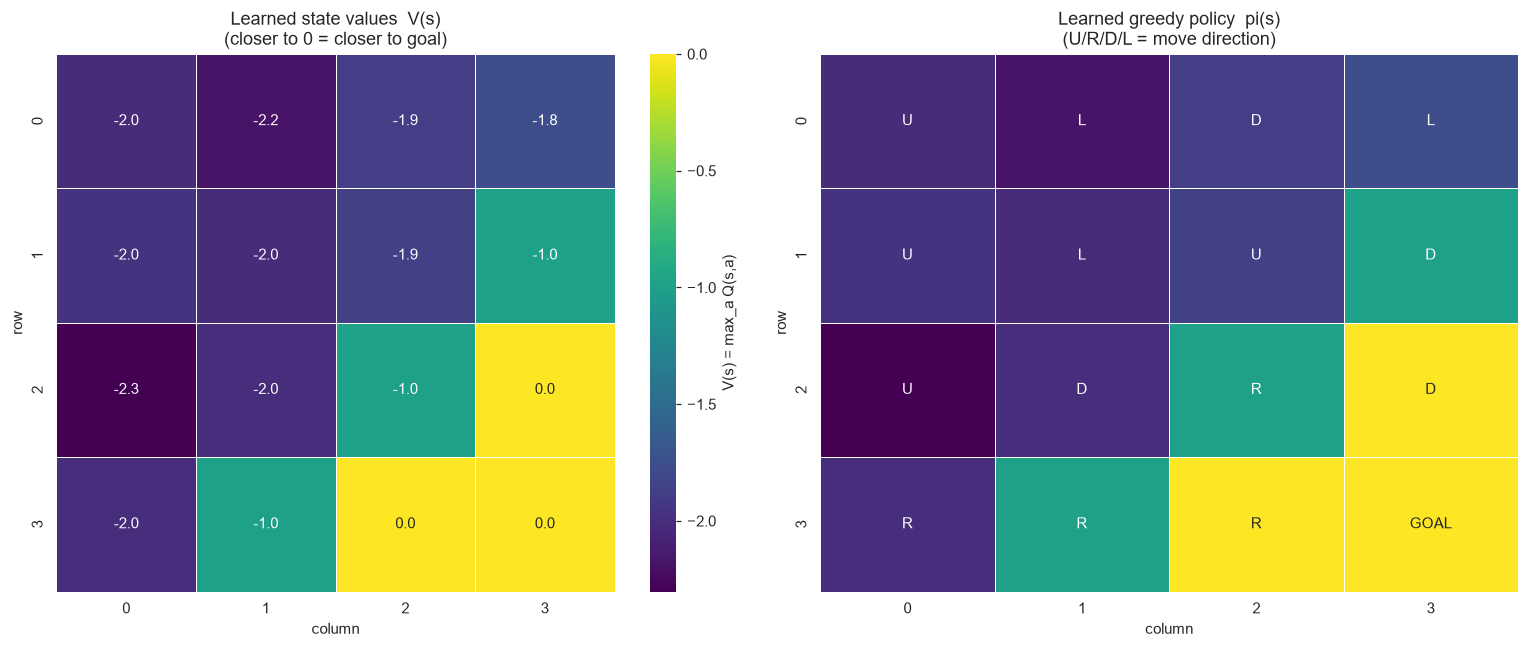

In [8]:
# Train for real
Q_ctrl, pi_ctrl = off_policy_mc_control(env, num_episodes=300_000, seed=GLOBAL_SEED)

# Build a state-value map V(s) = max_a Q(s,a) and an arrow map of the greedy policy
size = env.size
V = np.full((size, size), np.nan)
arrows = np.empty((size, size), dtype=object)
for r in range(size):
    for c in range(size):
        if (r, c) == env.goal:
            arrows[r, c] = 'GOAL'
            V[r, c] = 0.0
            continue
        if (r, c) in Q_ctrl:
            V[r, c] = np.max(Q_ctrl[(r, c)])
            arrows[r, c] = env.action_arrows[int(np.argmax(Q_ctrl[(r, c)]))]
        else:
            arrows[r, c] = '?'

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(V, annot=True, fmt='.1f', cmap='viridis',
            cbar_kws={'label': 'V(s) = max_a Q(s,a)'},
            ax=ax[0], linewidths=0.5, linecolor='white')
ax[0].set_title('Learned state values  V(s)\n(closer to 0 = closer to goal)')
ax[0].set_xlabel('column'); ax[0].set_ylabel('row')

sns.heatmap(V, annot=arrows, fmt='', cmap='viridis', cbar=False,
            ax=ax[1], linewidths=0.5, linecolor='white')
ax[1].set_title('Learned greedy policy  pi(s)\n(U/R/D/L = move direction)')
ax[1].set_xlabel('column'); ax[1].set_ylabel('row')

plt.tight_layout()
plt.show()

**What do we see here?**

- **Left:** the learned value `V(s)` grows (toward 0) as we approach the goal at the bottom-right — exactly what "fewest steps left" should look like.
- **Right:** the greedy moves mostly point **Right (R)** and **Down (D)**, i.e. *toward the goal*. The off-policy control algorithm recovered a sensible shortest-path policy purely from **random** behavior data, by re-weighting with importance sampling.
- States far from the goal are learned less confidently — the price of the inner-loop **break** discarding most of each random episode.

We've now run *both* pseudocodes. Time for the main event.

---
# Part 4 — The Variance Show: When Importance Sampling Explodes

This is the heart of the exercise. We return to the **one-state world** from Part 2 (true value = **1.0**) and compare two ways of averaging:

| Estimator | Formula | Personality |
|-----------|---------|-------------|
| **Ordinary IS** | $V = \dfrac{1}{N}\sum_{i} \rho_i\,G_i$ | Unbiased, but variance can be **infinite** |
| **Weighted IS** | $V = \dfrac{\sum_i \rho_i\,G_i}{\sum_i \rho_i}$ | Tiny bit biased, **dramatically** lower variance |

### Why does this world create monster weights?

An episode that goes LEFT exactly `k` times before terminating with the +1 reward has:

- **Return** `G = 1`.
- **Importance ratio** $\rho = \left(\tfrac{\pi(LEFT)}{b(LEFT)}\right)^k = \left(\tfrac{1}{0.5}\right)^k = 2^k$.

So the contribution `ρ·G = 2^k`. A run of 10 LEFTs contributes `2^10 ≈ 1024`; a run of 20 contributes over a **million**. These are *rare* but *gigantic* — the recipe for high variance.

One can show the variance is **infinite**: the second moment $\sum_k P(k)\,(2^k)^2$ contains $\sum_k (1.8)^{k}$, which **diverges**. We'll *see* that infinity as graphs that never calm down.

In [9]:
def sample_episode_weight(rng):
    """Simulate ONE behavior episode of the one-state world; return (rho*G, rho).

    Fast path: we don't need the full trajectory, just the importance contribution.
      - If the behavior ever picks RIGHT  -> pi(RIGHT)=0 -> rho = 0.
      - If it goes LEFT k times then ends with reward +1 -> rho = 2**k, G = 1.
    """
    k = 0
    while True:
        if rng.random() < 0.5:          # behavior chooses LEFT
            k += 1
            if rng.random() < 0.1:      # LEFT terminates with reward +1
                rho = 2.0 ** k
                return rho * 1.0, rho   # (rho*G, rho), with G = 1
            # else: back to s, keep going
        else:                            # behavior chooses RIGHT -> pi=0
            return 0.0, 0.0              # rho = 0, contributes nothing

def run_estimators(num_episodes, seed):
    """Run BOTH ordinary and weighted IS for num_episodes, recording the running
    estimate after every episode. Returns two arrays of length num_episodes."""
    rng = np.random.default_rng(seed)
    sum_rho_G = 0.0
    sum_rho   = 0.0
    ordinary  = np.empty(num_episodes)
    weighted  = np.empty(num_episodes)
    for i in range(num_episodes):
        rho_G, rho = sample_episode_weight(rng)
        sum_rho_G += rho_G
        sum_rho   += rho
        ordinary[i] = sum_rho_G / (i + 1)                        # divide by N
        weighted[i] = sum_rho_G / sum_rho if sum_rho > 0 else 0  # divide by sum of weights
    return ordinary, weighted

# Sanity check on a single run
ord_demo, wtd_demo = run_estimators(10_000, seed=1)
print("After 10,000 episodes (true value = 1.0):")
print(f"  Ordinary IS estimate: {ord_demo[-1]:.4f}")
print(f"  Weighted IS estimate: {wtd_demo[-1]:.4f}")

After 10,000 episodes (true value = 1.0):
  Ordinary IS estimate: 0.5704
  Weighted IS estimate: 1.0000


### Graph 1 — The "spaghetti" plot: ordinary IS never settles down

We run the **ordinary** estimator **10 independent times** (10 seeds) for up to **one million** episodes each, and overlay the running estimates on a **log** x-axis.

If variance were well-behaved, all 10 lines would hug the red `1.0` line ever more tightly. Watch what actually happens.

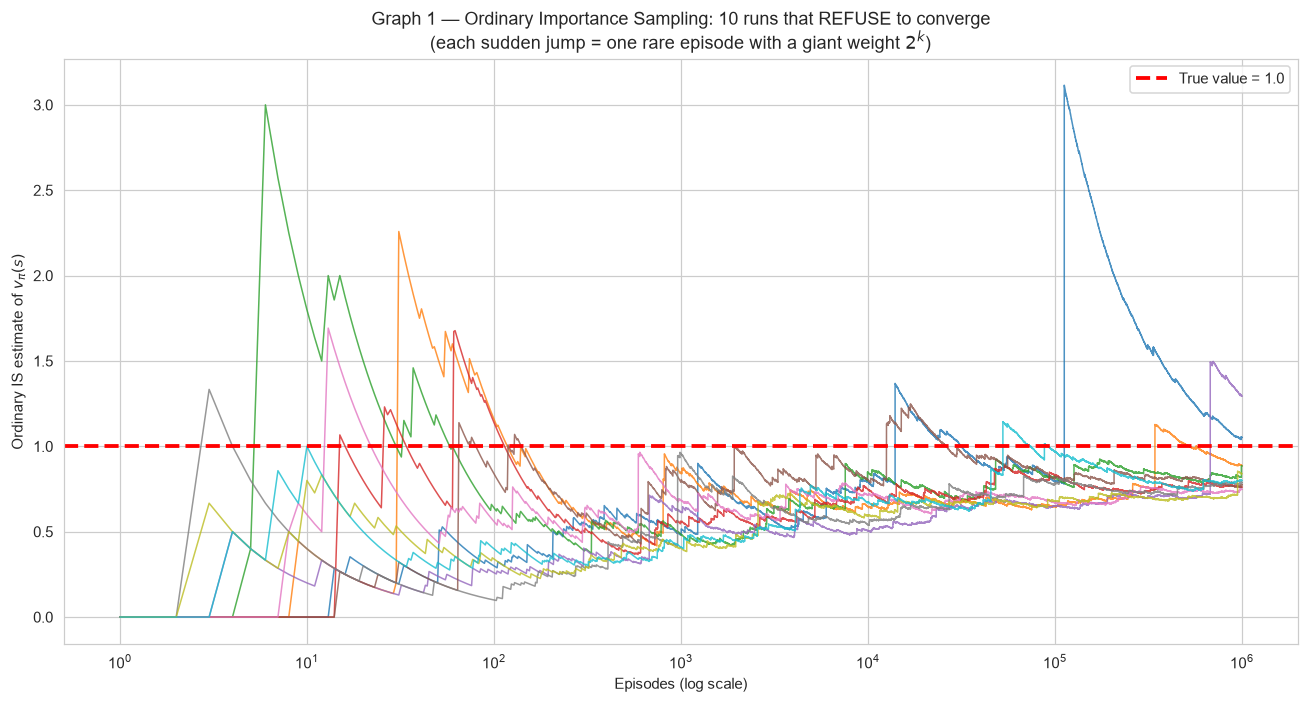

In [10]:
N_EPISODES = 1_000_000
N_RUNS = 10

plt.figure(figsize=(12, 6.5))
for run in range(N_RUNS):
    ordinary, _ = run_estimators(N_EPISODES, seed=1000 + run)
    plt.plot(np.arange(1, N_EPISODES + 1), ordinary, lw=1, alpha=0.8)

plt.axhline(1.0, color='red', ls='--', lw=2.5, label='True value = 1.0')
plt.xscale('log')
plt.xlabel('Episodes (log scale)')
plt.ylabel('Ordinary IS estimate of $v_\\pi(s)$')
plt.title('Graph 1 — Ordinary Importance Sampling: 10 runs that REFUSE to converge\n'
          '(each sudden jump = one rare episode with a giant weight $2^k$)')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insight — the signature of infinite variance:**

- Each line drifts toward 0, then **suddenly leaps upward** when a rare long all-LEFT episode lands a huge `2^k` weight.
- Even after **a million** episodes the runs are scattered — some near 0, some far above 1. They never agree.
- This is the "staircase that never flattens" from Sutton & Barto Figure 5.4. The estimator is *unbiased* (correct on average) yet *useless on any single run* — the hallmark of catastrophic variance.

### Graph 2 — Same world, weighted IS: calm and reliable

Now overlay the **weighted** estimator for the same 10 seeds. (In this world every contributing episode has `G = 1`, so weighted IS locks onto 1.0 almost instantly — a vivid contrast.)

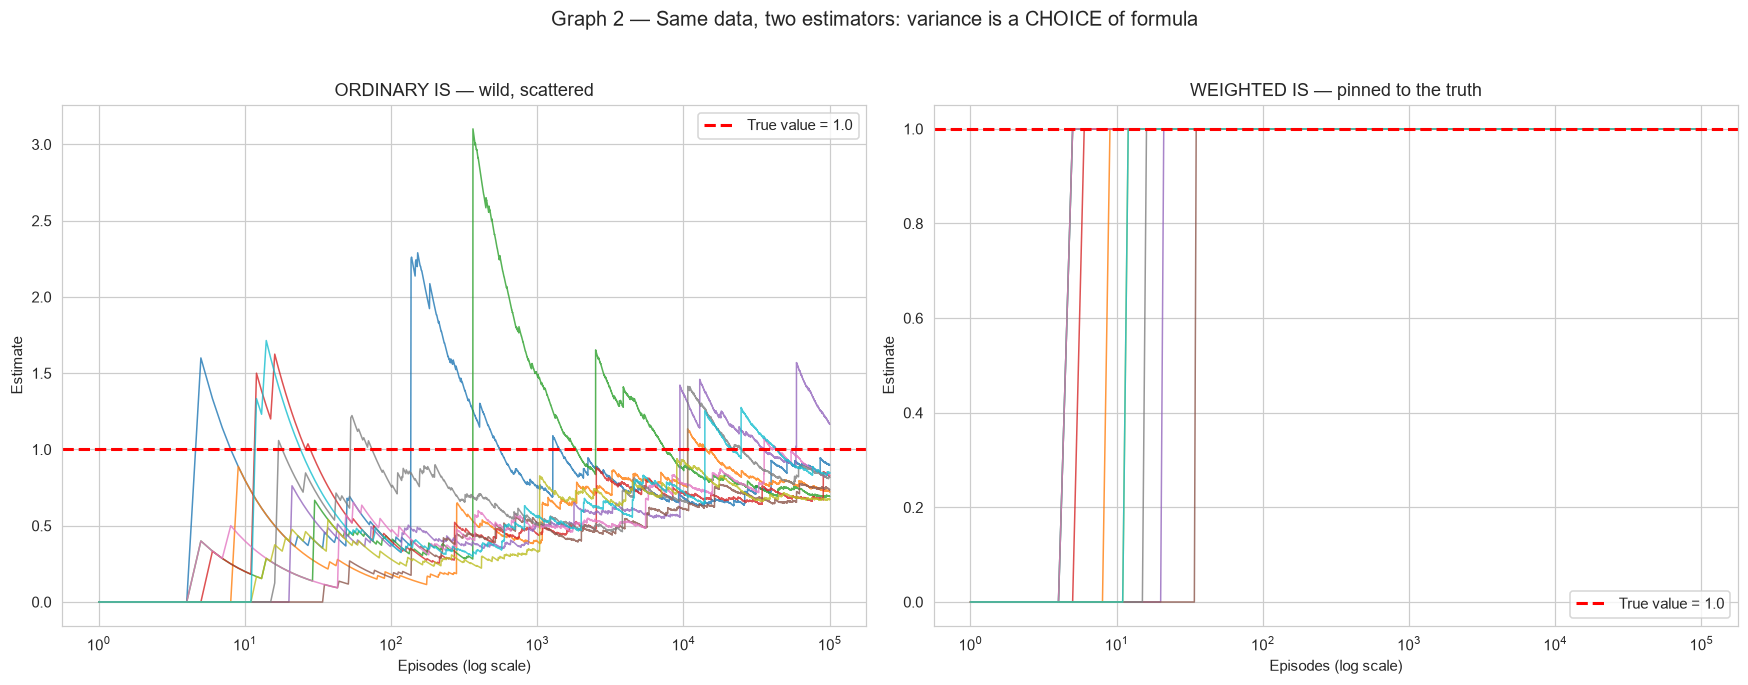

In [11]:
N_EPISODES_2 = 100_000
N_RUNS_2 = 10

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for run in range(N_RUNS_2):
    ordinary, weighted = run_estimators(N_EPISODES_2, seed=2000 + run)
    ax[0].plot(np.arange(1, N_EPISODES_2 + 1), ordinary, lw=1, alpha=0.8)
    ax[1].plot(np.arange(1, N_EPISODES_2 + 1), weighted, lw=1, alpha=0.8)

for a in ax:
    a.axhline(1.0, color='red', ls='--', lw=2, label='True value = 1.0')
    a.set_xscale('log'); a.set_xlabel('Episodes (log scale)'); a.legend()

ax[0].set_title('ORDINARY IS — wild, scattered'); ax[0].set_ylabel('Estimate')
ax[1].set_title('WEIGHTED IS — pinned to the truth'); ax[1].set_ylabel('Estimate')
plt.suptitle('Graph 2 — Same data, two estimators: variance is a CHOICE of formula', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

**What do we see here?**

- **Left (ordinary):** the same jittery, jumpy mess — divide-by-`N` lets rare giant weights dominate.
- **Right (weighted):** every run sits essentially **on top of** the true value. Dividing by the *sum of weights* normalises away the explosions.
- **Takeaway:** in this world, switching one denominator turns an unusable estimator into a rock-solid one. That's why weighted IS is the default in practice.

### Graph 3 — Where the variance comes from: the heavy tail of weights

Variance is caused by a few **enormous** values dragging the average around. Let's literally look at the distribution of the per-episode contribution `ρ·G`, on a **log scale** because the values span many orders of magnitude.

Of 200,000 episodes:
  18,257 (9.1%) had a NON-ZERO weight (all-LEFT runs)
  Largest single contribution rho*G seen: 8,192
  Mean contribution: 0.786   (should be ~1.0, and it's unbiased)


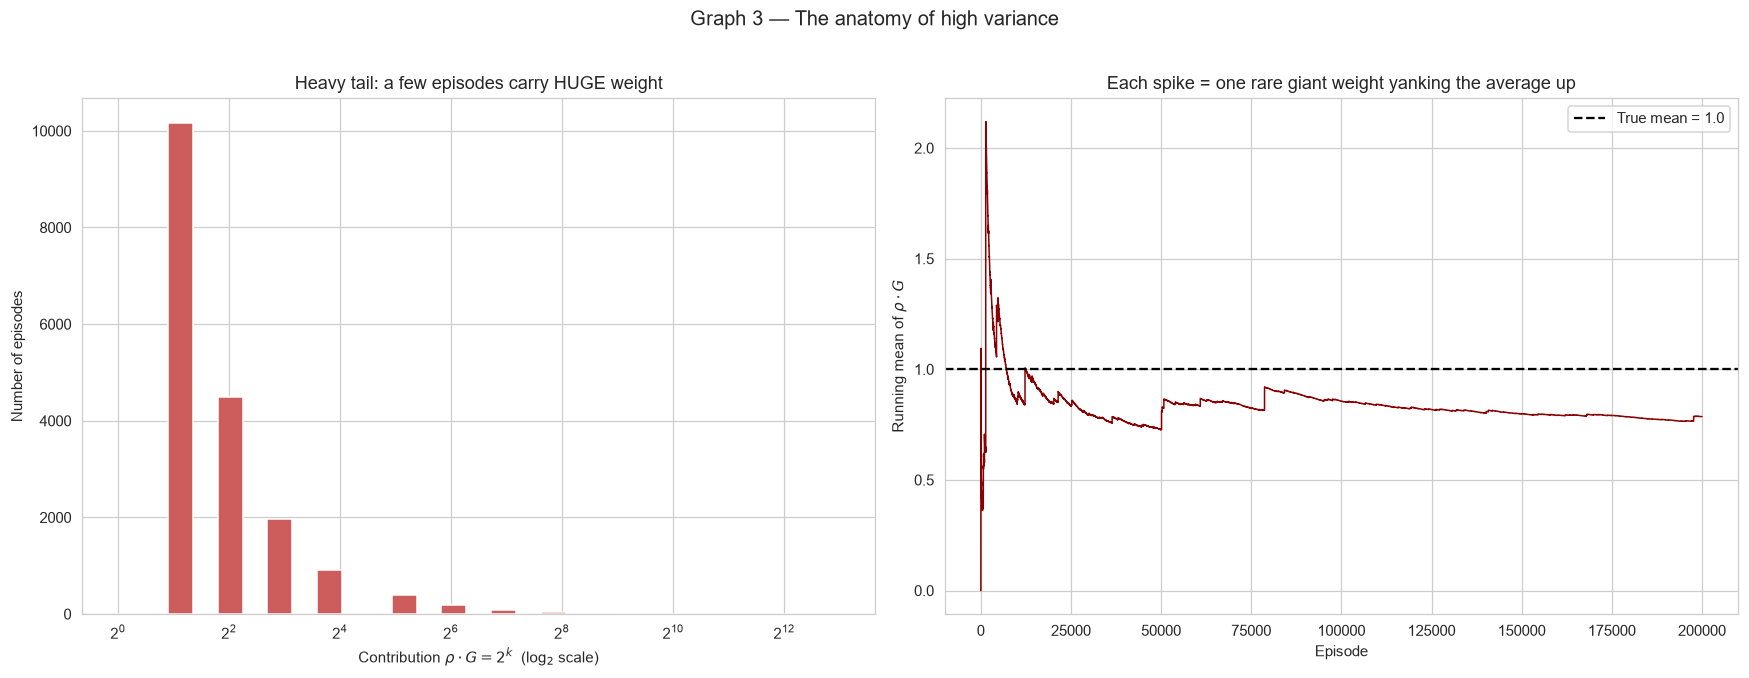

In [12]:
rng = np.random.default_rng(GLOBAL_SEED)
contributions = np.array([sample_episode_weight(rng)[0] for _ in range(200_000)])

nonzero = contributions[contributions > 0]   # episodes that actually count for pi
print("Of 200,000 episodes:")
print(f"  {len(nonzero):,} ({100*len(nonzero)/len(contributions):.1f}%) had a NON-ZERO weight (all-LEFT runs)")
print(f"  Largest single contribution rho*G seen: {contributions.max():,.0f}")
print(f"  Mean contribution: {contributions.mean():.3f}   (should be ~1.0, and it's unbiased)")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Left: histogram of the non-zero contributions on a log2 x-axis
bins = np.logspace(0, np.log10(nonzero.max()), 30)
ax[0].hist(nonzero, bins=bins, color='indianred', edgecolor='white')
ax[0].set_xscale('log', base=2)
ax[0].set_xlabel('Contribution $\\rho\\cdot G = 2^k$  (log$_2$ scale)')
ax[0].set_ylabel('Number of episodes')
ax[0].set_title('Heavy tail: a few episodes carry HUGE weight')

# Right: how a single running mean is yanked around by the rare giants
running_mean = np.cumsum(contributions) / np.arange(1, len(contributions) + 1)
ax[1].plot(running_mean, color='darkred', lw=1)
ax[1].axhline(1.0, color='black', ls='--', label='True mean = 1.0')
ax[1].set_xlabel('Episode'); ax[1].set_ylabel('Running mean of $\\rho\\cdot G$')
ax[1].set_title('Each spike = one rare giant weight yanking the average up')
ax[1].legend()

plt.suptitle('Graph 3 — The anatomy of high variance', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Key Insight:**

- **Left:** most non-zero contributions are small (`2`, `4`, `8`), but the tail stretches to **thousands or millions**. A tail this heavy can have an *undefined (infinite) variance*.
- **Right:** the running mean isn't gentle noise around a line — it's a series of **discrete jumps**, each one a single freak episode. An estimator built on this can't be trusted from one run.

### Graph 4 — The "value distribution": spread of the FINAL estimate across many runs

The exercise asks specifically about **variance in value distributions.** So we repeat the whole experiment **300 times** with a fixed, modest budget, and look at the *distribution of the final answer* each estimator reports. A trustworthy estimator → **tight** distribution around 1.0; a high-variance one → **wide, skewed** one.

After 50,000 episodes, across 300 independent runs (true value = 1.0):
  ORDINARY IS:  mean=0.978  std=2.441  min=0.564  max=42.598
  WEIGHTED IS:  mean=1.000  std=0.000  min=1.000  max=1.000


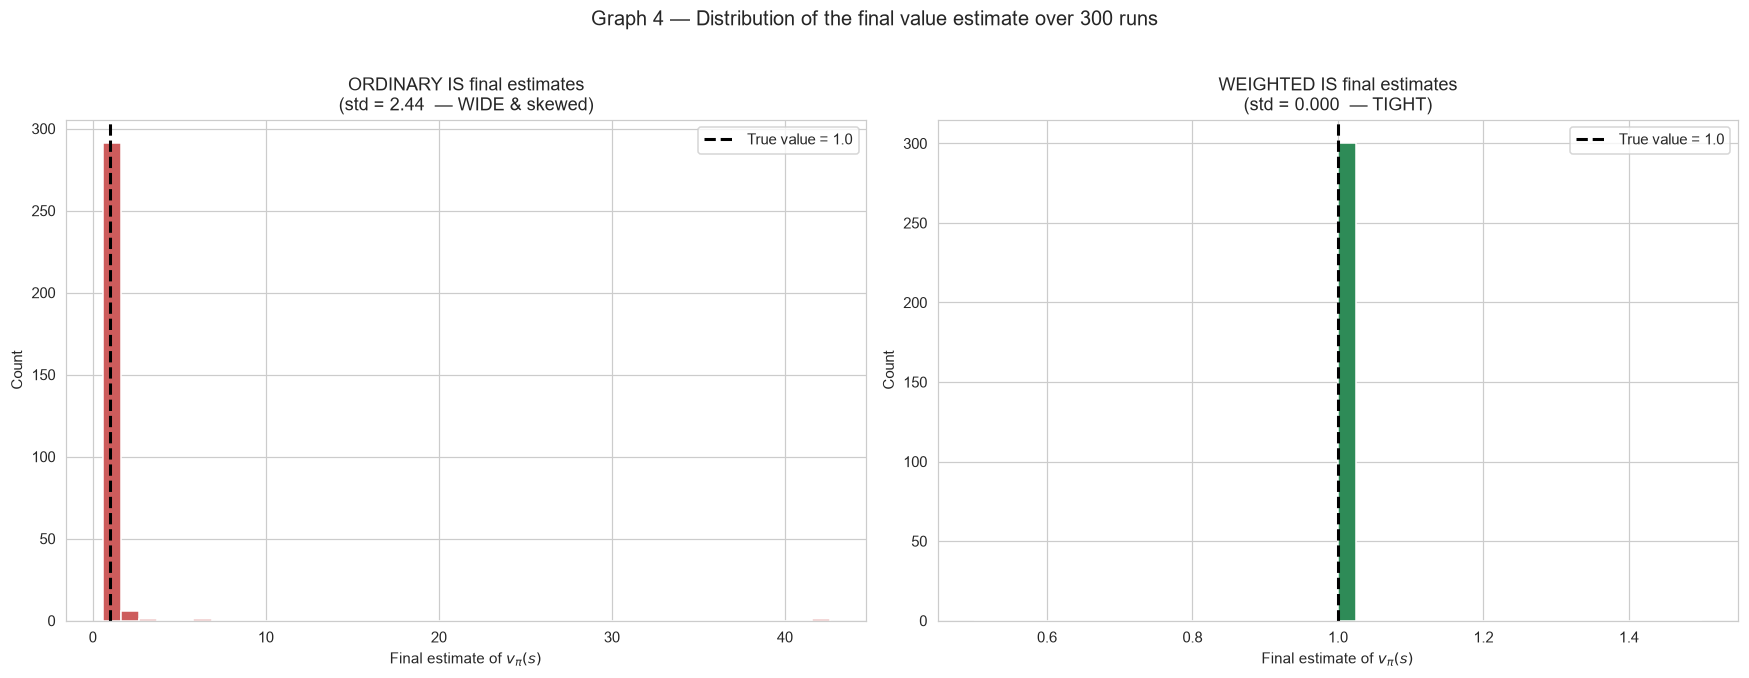

In [13]:
N_REPEATS = 300
BUDGET = 50_000

final_ordinary = np.empty(N_REPEATS)
final_weighted = np.empty(N_REPEATS)
for r in range(N_REPEATS):
    ordinary, weighted = run_estimators(BUDGET, seed=5000 + r)
    final_ordinary[r] = ordinary[-1]
    final_weighted[r] = weighted[-1]

print(f"After {BUDGET:,} episodes, across {N_REPEATS} independent runs (true value = 1.0):")
print(f"  ORDINARY IS:  mean={final_ordinary.mean():.3f}  std={final_ordinary.std():.3f}  "
      f"min={final_ordinary.min():.3f}  max={final_ordinary.max():.3f}")
print(f"  WEIGHTED IS:  mean={final_weighted.mean():.3f}  std={final_weighted.std():.3f}  "
      f"min={final_weighted.min():.3f}  max={final_weighted.max():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(final_ordinary, bins=40, color='indianred', edgecolor='white')
ax[0].axvline(1.0, color='black', ls='--', lw=2, label='True value = 1.0')
ax[0].set_title(f'ORDINARY IS final estimates\n(std = {final_ordinary.std():.2f}  — WIDE & skewed)')
ax[0].set_xlabel('Final estimate of $v_\\pi(s)$'); ax[0].set_ylabel('Count'); ax[0].legend()

ax[1].hist(final_weighted, bins=40, color='seagreen', edgecolor='white')
ax[1].axvline(1.0, color='black', ls='--', lw=2, label='True value = 1.0')
ax[1].set_title(f'WEIGHTED IS final estimates\n(std = {final_weighted.std():.3f}  — TIGHT)')
ax[1].set_xlabel('Final estimate of $v_\\pi(s)$'); ax[1].set_ylabel('Count'); ax[1].legend()

plt.suptitle('Graph 4 — Distribution of the final value estimate over 300 runs', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**What do we see here?**

- **Ordinary IS (left):** a **wide, lopsided** distribution. Many runs *under*-shoot (no giant weight arrived yet), a few wildly *over*-shoot. The big standard deviation is the variance you can present as a single number.
- **Weighted IS (right):** a **narrow spike** on 1.0. Same data, same budget — radically more reliable.
- This side-by-side *is* the "large variance in value distributions" the exercise asks for, made concrete.

### Graph 5 — Variance that doesn't shrink: the smoking gun

For a *well-behaved* estimator, the variance of the running mean should fall like `1/N` — more data, more certainty. We estimate the **variance of the ordinary-IS estimate across runs** at several episode budgets and see whether it actually shrinks.

budget=   1,000:  Var(ordinary)=     5.411   Var(weighted)=0.00000


budget=   5,000:  Var(ordinary)=     0.357   Var(weighted)=0.00000


budget=  20,000:  Var(ordinary)=     0.151   Var(weighted)=0.00000


budget= 100,000:  Var(ordinary)=     1.163   Var(weighted)=0.00000


budget= 500,000:  Var(ordinary)=     0.067   Var(weighted)=0.00000


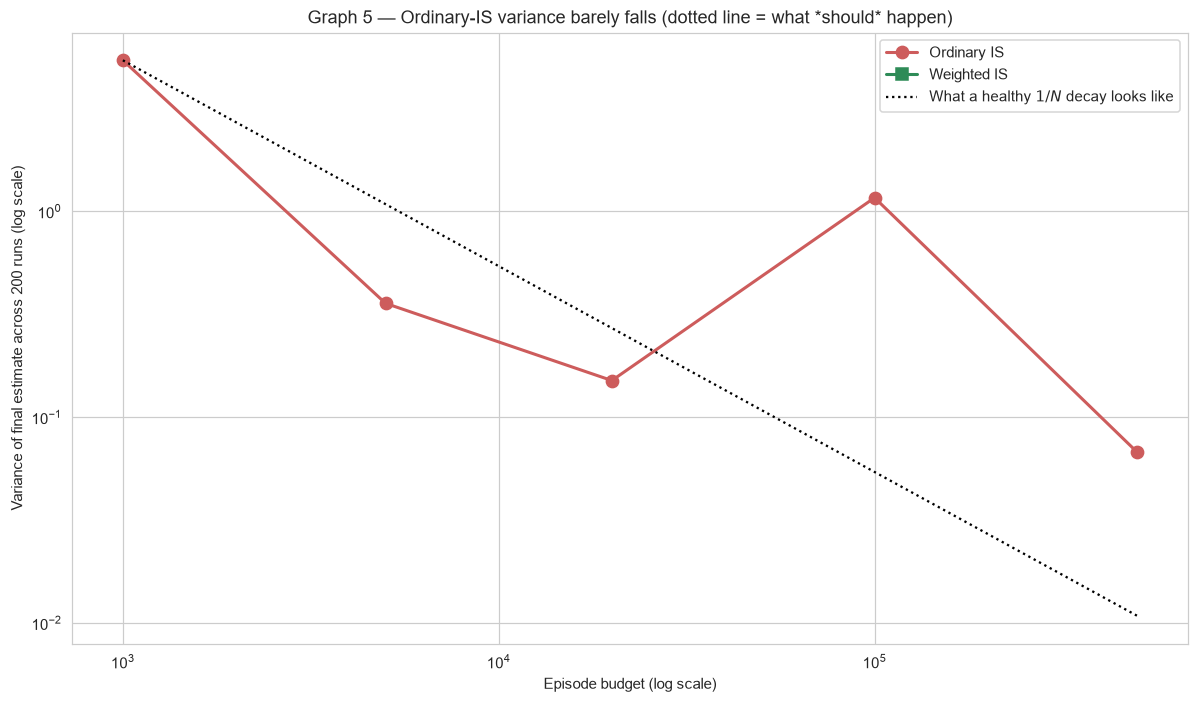

In [14]:
budgets = [1_000, 5_000, 20_000, 100_000, 500_000]
N_RUNS_VAR = 200

var_ordinary = []
var_weighted = []
for budget in budgets:
    finals_o, finals_w = [], []
    for r in range(N_RUNS_VAR):
        ordinary, weighted = run_estimators(budget, seed=9000 + r)
        finals_o.append(ordinary[-1])
        finals_w.append(weighted[-1])
    var_ordinary.append(np.var(finals_o))
    var_weighted.append(np.var(finals_w))
    print(f"budget={budget:>8,}:  Var(ordinary)={np.var(finals_o):10.3f}   Var(weighted)={np.var(finals_w):.5f}")

plt.figure(figsize=(11, 6.5))
plt.plot(budgets, var_ordinary, 'o-', color='indianred', lw=2, ms=8, label='Ordinary IS')
plt.plot(budgets, var_weighted, 's-', color='seagreen', lw=2, ms=8, label='Weighted IS')
# Reference line showing how a 'healthy' 1/N variance would fall
ref = var_ordinary[0] * budgets[0] / np.array(budgets, dtype=float)
plt.plot(budgets, ref, 'k:', lw=1.5, label='What a healthy $1/N$ decay looks like')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Episode budget (log scale)')
plt.ylabel('Variance of final estimate across 200 runs (log scale)')
plt.title('Graph 5 — Ordinary-IS variance barely falls (dotted line = what *should* happen)')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insight — the clincher:**

- The dotted line shows the `1/N` shrinkage we'd *hope* for: ten times the data → one tenth the variance.
- **Weighted IS** roughly follows that healthy decay.
- **Ordinary IS** does **not** — its variance stays stubbornly high and is hostage to whether a rare giant-weight episode happened to appear. That's the empirical fingerprint of (theoretically) **infinite** variance.

---
# Part 5 — Conclusion & Reflection

### Summary of what we built

| Deliverable (from the exercise) | Where | Result |
|---|---|---|
| Run the **MC Off-Policy Prediction** pseudocode | Part 2 | Weighted IS converges to the true value `1.0` |
| Run the **MC Off-Policy Control** pseudocode | Part 3 | Recovers a shortest-path policy on a 4×4 grid from *random* data |
| **Stubs showing key variables** (`G, W, C, Q`) | Parts 2 & 3 | Step-by-step traces print every variable named in the pseudocode |
| **Stubs showing large variance** | Part 4 | Five graphs: spaghetti, side-by-side, weight histogram, value-distribution, variance-vs-N |

### Key Takeaways

1. **Off-policy = learn about `π` while following `b`.** This is powerful because one stream of exploratory experience can teach us about *many* target policies — but it forces us to *correct* for the mismatch. That correction is importance sampling, and it is where all the trouble starts.

2. **The importance ratio is a product, and products explode.** Each step multiplies by `π/b`. When the policies disagree, a handful of trajectories accumulate astronomically large weights (`2^k` here). Because variance is driven by the *largest* values, those rare giants dominate everything — which is why a perfectly *unbiased* estimator can still be *useless* on any single run.

3. **Ordinary vs. weighted IS is the single most important practical choice.** They use the *same data*; they differ only in the denominator (`N` vs. `Σρ`). That one change took us from "never converges" (Graph 1) to "pinned to the truth" (Graph 2). In practice, **weighted IS is almost always preferred** for exactly this reason.

4. **Variance is visible, not just theoretical.** Graphs 4 and 5 turn the abstract phrase "high variance in value distributions" into pictures: a wide, skewed histogram of final answers, and a variance that refuses to shrink with more data.

### What surprised us?

The most counter-intuitive result is that **more data did not fix ordinary IS** (Graph 5). Our whole intuition from statistics is "average enough samples and the noise washes out." But that rule assumes *finite* variance. Here the second moment diverges (`Σ 1.8^k → ∞`), so the usual `1/N` safety net is gone — the average can be yanked around by a single freak episode no matter how many episodes precede it.

### What trade-offs were made?

- **Ordinary vs. weighted IS** — *unbiasedness vs. variance*. Ordinary IS is exactly unbiased but has (here) infinite variance; weighted IS accepts a small bias for enormously lower variance. For almost any real task, that trade is worth it.
- **Simple world vs. realism** — we deliberately chose the *one-state* MDP because it makes the variance explosion mathematically clean and easy to *see*. A messier environment would hide the mechanism behind noise.
- **Episode budget vs. runtime** — we capped the spaghetti plot at 1,000,000 episodes (not Sutton's 10⁸) so the notebook runs in a classroom-friendly time while still clearly showing non-convergence.

### Limitations (honest)

- The one-state world is a *worst case* designed to expose variance; not every off-policy problem is this extreme.
- In *this* world weighted IS looks almost magically perfect because every contributing return equals `1` — real problems have varied returns, so weighted IS won't be quite so flawless (just much better than ordinary).
- Our control demo learns slowly far from the goal because the inner-loop **break** discards most of each random episode — a real, known weakness of vanilla off-policy MC control.

### What could be improved / next steps

- **Discounting-aware** and **per-decision** importance sampling reduce variance by not multiplying ratios past where they matter.
- **Weighted IS everywhere**, plus *clipping* or *truncating* the ratios (as modern algorithms like PPO effectively do).
- For control: a **less random behavior policy** (e.g. ε-greedy that already leans toward the current best action) keeps more of each episode and learns far faster.
- Compare against **Temporal-Difference** methods (next week!), which sidestep importance-sampling products by bootstrapping one step at a time.

### The big picture

Importance sampling is the bridge that lets an agent learn from *someone else's* experience — the same idea that powers learning from logged data, from human demonstrations, and from old policies in modern deep-RL. Today we saw both its **power** (learn about `π` from `b`) and its **Achilles heel** (variance that can blow up to infinity). Knowing *when* the bridge is sturdy and *when* it sways in the wind is exactly the judgement a good RL practitioner needs.